# Topic 2.9 - Pandas 中自带的画图功能

在本节开始前，我们先导入一下 Pandas 库：

In [218]:
import pandas as pd
import random

## 1. Pandas 的绘图功能简介

在数据分析的可视化任务中：

- 常用的作图库是 Matplotlib 和 Seaborn
- 但实际上 Pandas 库本身也内置了一些基本的绘图功能，能够满足一些简单的数据可视化需求
- 和专门的作图库相比，Pandas 的绘图功能相对简单，适合快速生成一些基础的图表，讲究的是方便快捷，而不是复杂和美观
- 如果作图目标是快速发现数据中的趋势和模式，Pandas 的绘图功能是一个不错的选择

总的来说，Pandas 绘图的基本语法是 `DataFrame.plot()` 或 `Series.plot()`：

- 也就是直接在 DataFrame 或 Series（可以是 DataFrame 的一列或一行） 对象上调用 `plot()` 方法
- 然后指定图表类型和相关参数即可，例如图表类型、数据列、标题、标签等

## 2. 常见的图表类型及其绘制方法

### (1) 折线图

折线图是最常见的图表类型之一，适合展示数据随时间或其他连续变量的变化趋势。

我们先来准备一组时间序列数据，然后绘制折线图，最好将 index 设置为时间序列，以便更直观地展示数据的变化趋势：

In [219]:
df1 = pd.DataFrame({
    "A": [random.randrange(1, 100) for _ in range(10)],
    "B": [random.randrange(1, 100) for _ in range(10)],
    "C": [random.randrange(1, 100) for _ in range(10)],
}, index=pd.date_range("2023-01-01", periods=10))

df1

,A,B,C
2023-01-01,13,98,97
2023-01-02,35,7,64
2023-01-03,34,65,21
2023-01-04,69,4,43
2023-01-05,46,42,64
2023-01-06,43,84,89
2023-01-07,29,34,16
2023-01-08,14,98,45
2023-01-09,1,27,5
2023-01-10,29,47,68


- 如果只画一列对应的一条线，可以直接在一列上调用 `plot()` 方法，并强调 `kind='line'`：

<Axes: >

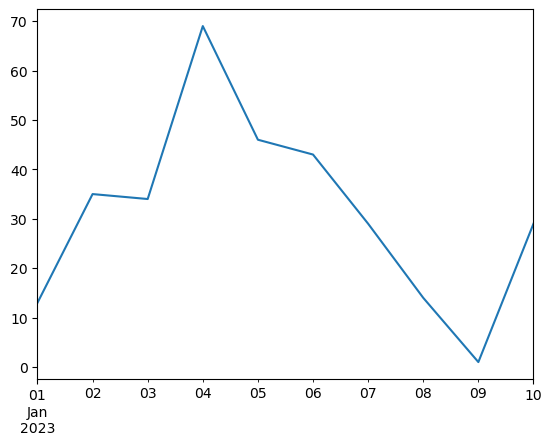

In [220]:
df1["A"].plot(kind='line')

- 如果想将多条线绘制在同一张图上，可以直接在 DataFrame 上调用 `plot()` 方法，并在 `y` 参数中指定多列数据：

<Axes: >

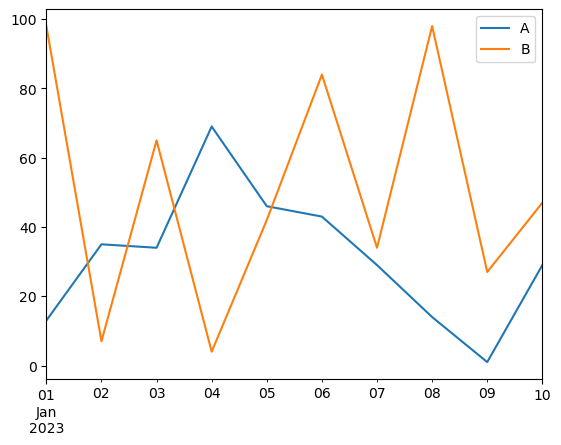

In [221]:
df1.plot(y=["A", "B"], kind='line')

- 如果将所有列都绘制在同一张图上，可以直接在 DataFrame 上调用 `plot()` 方法而不指定列：

<Axes: >

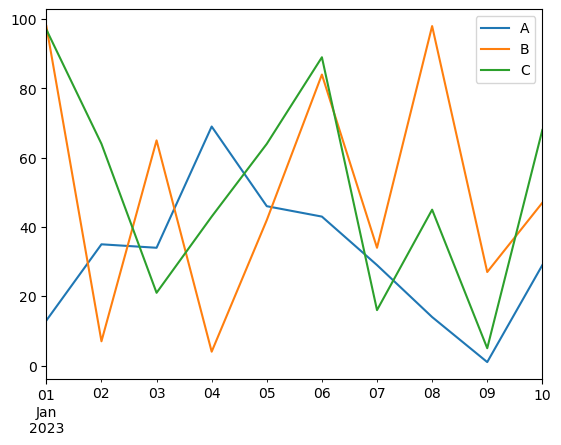

In [222]:
df1.plot(kind='line')

### (2) 柱状图

柱状图适合展示不同类别之间的比较，常用于显示分类数据的分布情况。

首先，我们准备一组分类数据，然后绘制柱状图，柱状图的数据通常是离散的类别和对应的数值：

In [223]:
df2 = pd.DataFrame({
    "A": [random.randrange(10, 100) for _ in range(4)],
    "B": [random.randrange(10, 100) for _ in range(4)],
    "C": [random.randrange(10, 100) for _ in range(4)]
}, index=["Q1", "Q2", "Q3", "Q4"])

df2

,A,B,C
Q1,83,62,78
Q2,57,17,87
Q3,33,16,13
Q4,49,14,25


- 如果想绘制普通柱状图，我们要在 DataFrame 上调用 `plot()` 方法，指定 `y` 参数来绘制柱状图，并强调 `kind='bar'`：

<Axes: >

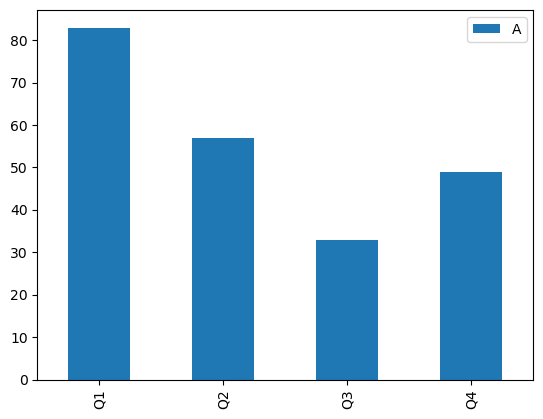

In [224]:
df2.plot(y=['A'], kind='bar')

- 如果绘制分组柱状图，则可以在 DataFrame 上调用 `plot()` 方法，指定 `kind='bar'`，Pandas 会自动将不同类别的数据分组显示：

    - 和折线图一样，如果想绘制多列数据，可以在 `y` 参数中指定多列数据
    - 而如果想要绘制所有列的数据，可以直接在 DataFrame 上调用 `plot()` 方法而不指定 `y` 参数 

<Axes: >

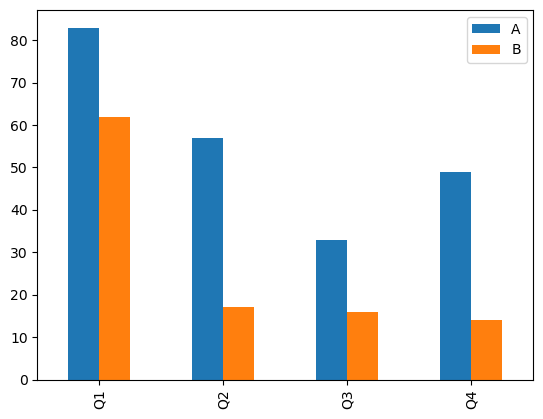

In [225]:
df2.plot(y =['A', 'B'], kind='bar')

<Axes: >

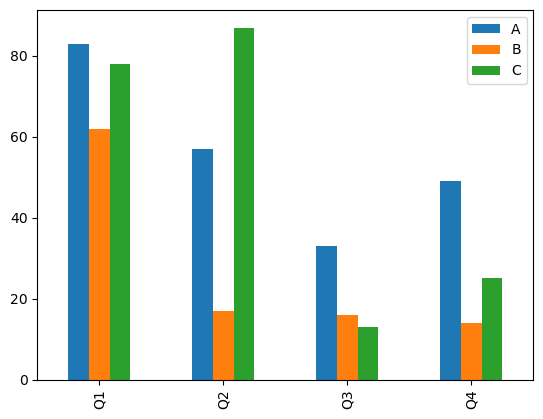

In [226]:
df2.plot(kind='bar')

- 如果想绘制堆叠柱状图，可以在 `plot()` 方法中指定 `kind='bar'` 并设置 `stacked=True` 参数：

    - 同样，如果想绘制多列数据，可以在 `y` 参数中指定多列数据
    - 如果想要绘制所有列的数据，可以直接在 DataFrame 上调用 `plot()` 方法而不指定 `y` 参数

<Axes: >

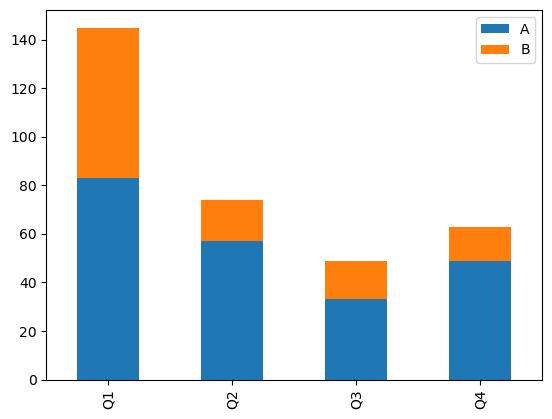

In [227]:
df2.plot(y=['A', 'B'], kind='bar', stacked=True)

<Axes: >

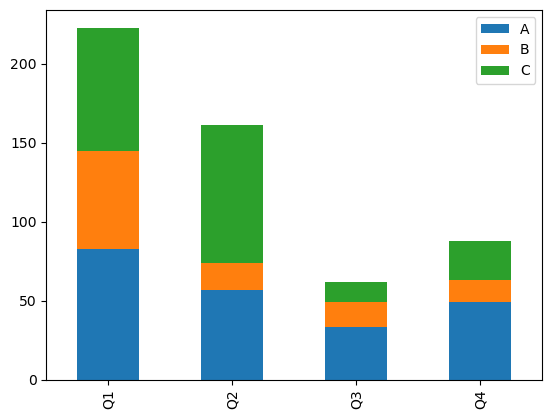

In [228]:
df2.plot(kind='bar', stacked=True)

### (3) 饼状图

饼状图适合展示各部分在整体中所占的比例，常用于显示分类数据的组成情况。

首先，我们准备一组分类数据，然后绘制饼状图，饼状图通常用于显示单个类别的比例分布：

In [229]:
df3 = pd.DataFrame({
    "A": [random.randrange(10, 100) for _ in range(4)],
    "B": [random.randrange(10, 100) for _ in range(4)],
    "C": [random.randrange(10, 100) for _ in range(4)]
}, index=["Q1", "Q2", "Q3", "Q4"])

df3

,A,B,C
Q1,83,39,63
Q2,35,82,18
Q3,95,95,70
Q4,30,14,81


- 在 Pandas 中，饼图和折线图、柱状图有所不同，因为饼图通常是针对单个 Series（即单列数据）进行绘制的：

    - 因此，我们需要先选择 DataFrame 中的一列或一行数据，然后在该列上调用 `plot()` 方法，并指定 `kind='pie'` 参数即可绘制饼图
    - 在整个 DataFrame 上调用 `plot()` 方法是无法直接绘制饼图的

- 我们先来看选用一列数据绘制饼图的例子，在上面的数据中，它展示的是同一商品在各季度的销售比例：

<Axes: ylabel='A'>

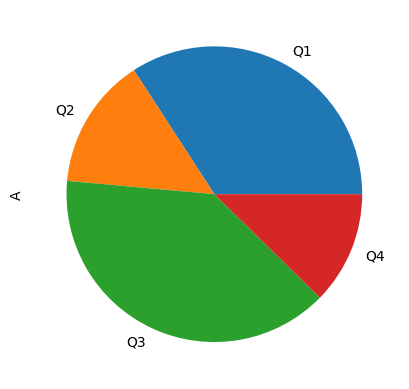

In [230]:
df3["A"].plot(kind='pie')

- 我们再来看选用一行数据绘制饼图的例子，这次展示的是各商品在某一季度的销售比例：

<Axes: ylabel='Q1'>

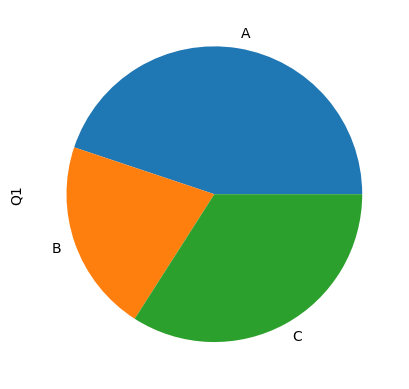

In [231]:
df3.loc["Q1"].plot(kind='pie')

### (4) 散点图

散点图常用的情景是展示两个变量之间的关系，适合用于探索数据中的相关性。

首先，我们准备一组包含两个变量的数据，然后绘制散点图，要注意散点图的 X 和 Y 都应该是数值型数据：

In [232]:
df4 = pd.DataFrame({
    "X": [random.uniform(1, 100) for _ in range(20)],
    "Y": [random.uniform(1, 100) for _ in range(20)],
})

df4

,X,Y
0,51.553462,22.586876
1,53.622465,38.644271
2,7.567322,37.656261
3,90.576675,44.737475
4,92.856210,17.032500
5,55.166151,31.707984
6,64.575843,53.156904
7,95.589727,58.635147
8,12.628597,78.055815
9,91.520935,11.524723


在绘制散点图的时候，我们需要指定 `x` 和 `y` 参数来分别表示横轴和纵轴的数据列，并强调 `kind='scatter'` 参数：

<Axes: xlabel='X', ylabel='Y'>

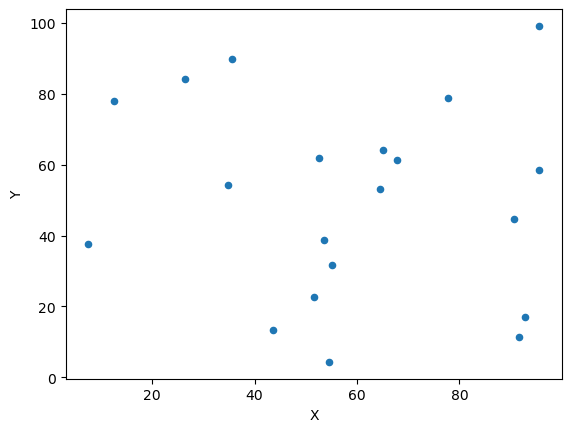

In [233]:
df4.plot(kind='scatter', x='X', y='Y')

### (5) 其他的图表类型

事实上，通过上面几种常见的图表类型，大家已经可以体会到 Pandas 绘图功能的基本用法了：

- 其实就是在 DataFrame 或 Series 对象上调用 `plot()` 方法
- 之后，指定 `kind` 参数来选择图表类型
- 使用 `x` 和 `y` 参数来指定数据列

Pandas 当中还支持其他类型的图表，我们这里就不一一展示了，这些图表都符合上述的基本用法：

- 箱线图（Box Plot）：`kind='box'`
- 直方图（Histogram）：`kind='hist'`
- 面积图（Area Plot）：`kind='area'`
- 等等

## 3. 常见的图表装饰方法

在 `plot()` 方法中，我们还可以使用一些常见的参数来装饰图表，使其更具可读性和美观性。

### (1) 添加标题和标签

在 `plot()` 方法中，添加文字标题和标签的方法包括：

- `title`：设置图表标题
- `xlabel`：设置 X 轴标签
- `ylabel`：设置 Y 轴标签

In [234]:
df5 = pd.DataFrame({
    "A": [random.randrange(10, 100) for _ in range(4)],
    "B": [random.randrange(10, 100) for _ in range(4)],
    "C": [random.randrange(10, 100) for _ in range(4)]
}, index=["Q1", "Q2", "Q3", "Q4"])

df5

,A,B,C
Q1,76,16,11
Q2,77,18,56
Q3,63,21,86
Q4,81,30,86


<Axes: title={'center': 'Sales Over Quarters'}, xlabel='Quarter', ylabel='Sales Amount'>

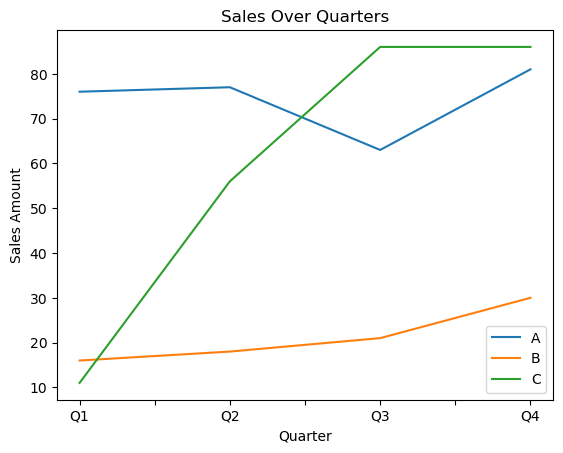

In [235]:
df5.plot(kind='line',
         title='Sales Over Quarters',
         xlabel='Quarter',
         ylabel='Sales Amount')

### (2) 设置图例

图例通常是 `plot()` 函数自动生成的，但我们也可以通过 `legend` 参数来控制图例的显示：

- `legend=True`：显示图例
- `legend=False`：隐藏图例

<Axes: title={'center': 'Sales Over Quarters'}, xlabel='Quarter', ylabel='Sales Amount'>

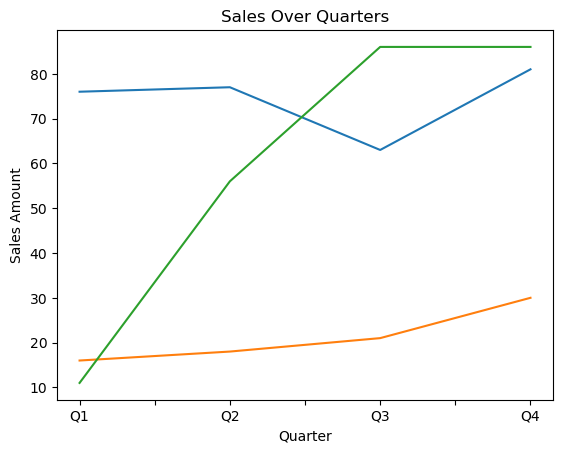

In [236]:
df5.plot(kind='line',
         title='Sales Over Quarters',
         xlabel='Quarter',
         ylabel='Sales Amount',
         legend=False)

### (3) 设置图表大小

在 `plot()` 方法中，可以使用 `figsize` 参数来设置图表的大小：

- 这个方法传入一个元组 `figsize=(width, height)`：指定图表的宽度和高度，单位为英寸
- 这里的英寸指的是物理尺寸，而不是像素尺寸，因此实际显示效果还会受到显示设备分辨率的影响

<Axes: title={'center': 'Sales Over Quarters'}, xlabel='Quarter', ylabel='Sales Amount'>

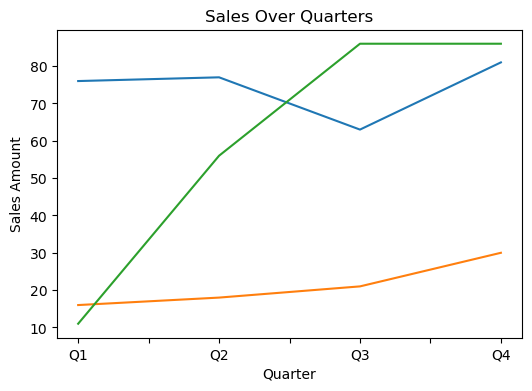

In [237]:
df5.plot(kind='line',
         title='Sales Over Quarters',
         xlabel='Quarter',
         ylabel='Sales Amount',
         legend=False,
         figsize=(6, 4))

## 4. Pandas 自带图表与 Matplotlib 的关系

事实上，Pandas 自带的绘图功能实际上是基于 Matplotlib 库实现的：

- 因此，我们可以在使用 Pandas 绘图时，同时利用 Matplotlib 的一些高级功能来进一步定制图表
- 而且之后，我们学到一些 Matplotlib 的知识后，也可以将其应用到 Pandas 绘图中，从而实现更复杂和美观的图表效果
- 这里我们举个例子，比方说，我们可以使用 Pandas 绘制一个简单的折线图，然后利用 Matplotlib 来添加更多的自定义元素，比如网格线、注释等：

In [238]:
df5 = pd.DataFrame({
    "A": [random.randrange(10, 100) for _ in range(4)],
    "B": [random.randrange(10, 100) for _ in range(4)],
    "C": [random.randrange(10, 100) for _ in range(4)]
}, index=["Q1", "Q2", "Q3", "Q4"])

df5

,A,B,C
Q1,64,42,55
Q2,69,52,92
Q3,44,57,48
Q4,41,83,38


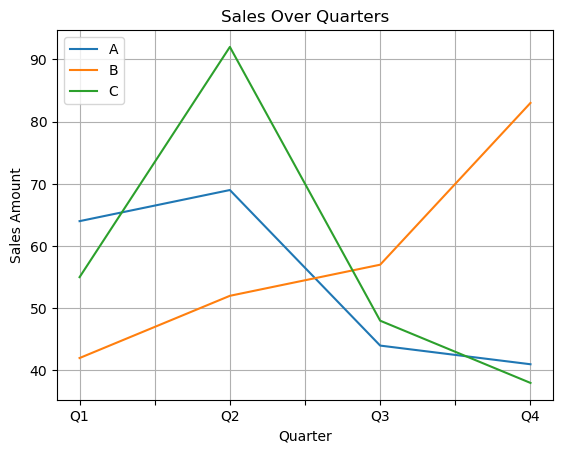

In [241]:
import matplotlib.pyplot as plt

df5.plot(kind='line',
         title='Sales Over Quarters',
         xlabel='Quarter',
         ylabel='Sales Amount')

plt.grid(True)
plt.show()

当然，两种库的绘图代码混用可能会有些问题：

- 一是版本冲突和兼容性的问题
- 二是代码风格和习惯的问题
- 因此，在实际项目中，建议尽量选择一种绘图库进行绘图，避免混用带来的潜在问题